In [ ]:
import numpy as np
from scipy.special import gamma
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import time

In [ ]:
# Function to construct the psi matrix
def psi_matrix(alpha, j):
    """
    Constructs the diagonal matrix psi(alpha, j) based on the provided formula.
    """
    diagonal_elements = [
        gamma(j - alpha[i]) / (gamma(-alpha[i]) * gamma(j + 1)) for i in range(len(alpha))
    ]
    return np.diag(diagonal_elements)

# Function to generate data for a single trial
def generate_data_single_trial(p, A, B, alpha, x_0, u_0, j=1):
    """
    Generates x_0, u_0, and x_1 for a single trial.
    Args:
        p (int): Number of initial conditions.
        A (np.ndarray): System matrix.
        B (np.ndarray): Input matrix.
        C_alpha (np.ndarray): Diagonal matrix derived from alpha.
        alpha (np.ndarray): Diagonal elements of C_alpha.
        j (int): Time step for psi computation (default is 1).
        x_0 (np.ndarray): Initial conditions (p x n).
        u_0 (np.ndarray): Control inputs (p x n).
    
    Returns:
        x_1 (np.ndarray): Generated states at the second time step (p x n).
    """
    n = B.shape[0]

    #x_0 = np.random.rand(p, n)  # Initial conditions
    #u_0 = np.random.rand(p, m)  # Control inputs
    w_0 = np.random.randn(p, n)  # Gaussian noise
    #w_0 = np.zeros((p,n))
    x_1 = np.zeros((p, n))  # Placeholder for x_1

    # Compute x_1 for each initial condition
    psi_diag = psi_matrix(alpha, j)  # Compute psi for time step j
    for i in range(p):
        x_1[i, :] = (
            np.dot(A, x_0[i, :]) 
            + np.dot(B, u_0[i, :]) 
            - np.dot(psi_diag, x_0[i, :]) 
            + w_0[i, :]
        )
    
    return x_0, u_0, x_1

# Function to generate data for multiple trials
def generate_data_multiple_trials(N, p, A, B, alpha, x_0, u_0):
    """
    Generates x_0, u_0, and x_1 across multiple trials.
    Args:
        N (int): Number of trials.
        p (int): Number of initial conditions.
        A (np.ndarray): System matrix.
        B (np.ndarray): Input matrix.
        alpha (np.ndarray): Diagonal elements of C_alpha.
    
    Returns:
        x_0_all (np.ndarray): All initial conditions (N x p x n).
        u_0_all (np.ndarray): All control inputs (N x p x n).
        x_1_all (np.ndarray): All generated states (N x p x n).
    """
    

    # Storage for all trials
    x_0_all = []
    u_0_all = []
    x_1_all = []

    for trial in range(N):
        x_0, u_0, x_1 = generate_data_single_trial(p, A, B, alpha, x_0, u_0)
        x_0_all.append(x_0)
        u_0_all.append(u_0)
        x_1_all.append(x_1)
    
    # Convert to numpy arrays
    x_0_all = np.array(x_0_all)
    u_0_all = np.array(u_0_all)
    x_1_all = np.array(x_1_all)
    
    return x_0_all, u_0_all, x_1_all

# Function to construct the block diagonal matrix (π or φ)
def construct_block_diagonal_matrix(data, n):
    """
    Constructs a block diagonal matrix for π or φ.
    Args:
        data (np.ndarray): Input data (x_0 or u_0) of shape (p, n).
        n (int): state
    
    Returns:
        np.ndarray: Block diagonal matrix of shape (p * n, n).
    """
    m = data.shape[2]
    p = data.shape[1]  # Number of initial conditions
    matrix = np.zeros((n * p, n * m))

    for i in range(p):
        for j in range(n):
            matrix[i * n + j, j * m : (j + 1) * m] = data[0, i]  
    return matrix

# Function to construct the diagonal matrix Ω
def construct_diagonal_matrix(data):
    """
    Constructs a diagonal matrix Ω from x_0.
    Args:
        data (np.ndarray): Input data (x_0) of shape (p, n).
    
    Returns:
        np.ndarray: Diagonal matrix of shape (p * n, n).
    """
    p, n = data[0].shape
    diagonal_matrix = np.zeros((p * n, n))
    for i in range(p):
        diagonal_matrix[i * n:(i + 1) * n, :] = np.diag(data[0, i])
    return diagonal_matrix


# Function to solve the least squares problem known A and \alpha
def solve_least_squares_know_A_alpha(X, x_0, u_0, A, alpha):
    """
    Solves the least squares problem described in the equations.
    Args:
        X (np.ndarray): Target data matrix of shape (N, p, n).
        x_0 (np.ndarray): Initial conditions (N, p, n).
        u_0 (np.ndarray): Control inputs (N, p, m).

    Returns:
        theta_hat (np.ndarray): Estimated parameter vector [gamma, beta, alpha].
    """
    n = x_0.shape[2]
    m = u_0.shape[2]

    # Construct π, φ, and Ω
    pi = construct_block_diagonal_matrix(x_0, n)
    phi = construct_block_diagonal_matrix(u_0, n)
    omega = construct_diagonal_matrix(x_0)

    pi_A = pi @ A.reshape(-1)
    Omega_alpha = omega @ alpha


    # Construct the matrix ξ
    xi = np.hstack([phi])  # Shape: (p * n, 3 * n)
    #print(xi)
    #print(xi.T @ xi)
    #print((xi.T @ xi).shape)
    # Solve the least squares problem
    theta_hat = np.linalg.inv(xi.T @ xi) @ xi.T @ (np.mean(X, axis = 0).reshape(-1) - pi_A - Omega_alpha)

    
    # Reshape theta_hat into A_hat and B_hat
    #A_alpha_hat = theta_hat[:n**2].reshape(n, n)
    #B_hat = theta_hat[n**2:].reshape(n, m)

    #return A_alpha_hat, B_hat
    return theta_hat

def replace_diagonal_and_compute_difference(A_alpha_hat, diagonal_A):
    """
    Replaces the diagonal elements of A_alpha_hat with diagonal_A 
    and computes the difference between the original and new diagonal elements.

    Parameters:
    A_alpha_hat (numpy.ndarray): An n x n matrix.
    diagonal_A (numpy.ndarray): An n x 1 vector.

    Returns:
    tuple: A_hat (n x n matrix), alpha_hat (n x 1 vector).
           A_hat is A_alpha_hat with its diagonal replaced by diagonal_A.
           alpha_hat is the difference between the original and new diagonal elements.
    """
    # Validate inputs
    n = A_alpha_hat.shape[0]
    if A_alpha_hat.shape[0] != A_alpha_hat.shape[1]:
        raise ValueError("A_alpha_hat must be an n x n square matrix.")
    if diagonal_A.shape[0] != n or diagonal_A.shape[1] != 1:
        raise ValueError("diagonal_A must be an n x 1 vector.")

    # Extract original diagonal elements of A_alpha_hat
    original_diagonal = np.diag(A_alpha_hat)

    # Compute alpha_hat as the difference between original and new diagonal
    alpha_hat = (original_diagonal - diagonal_A.flatten()).reshape(-1, 1)

    # Replace the diagonal of A_alpha_hat with diagonal_A
    A_hat = A_alpha_hat.copy()
    np.fill_diagonal(A_hat, diagonal_A.flatten())

    return A_hat, alpha_hat

def extract_diagonal(A):
    """
    Extracts the diagonal elements of a square matrix A and forms a column vector.

    Parameters:
    A (numpy.ndarray): An n x n matrix.

    Returns:
    numpy.ndarray: An n x 1 vector containing the diagonal elements of A.
    """
    # Validate input
    if A.shape[0] != A.shape[1]:
        raise ValueError("Input matrix A must be square (n x n).")
    
    # Extract the diagonal elements and reshape into a column vector
    diagonal_vector = np.diag(A).reshape(-1, 1)
    
    return diagonal_vector

# Define the ψ(α_i, j) function
def psi(alpha_i, j):
    """
    Compute ψ(α_i, j) = Γ(j - α_i) / (Γ(-α_i) Γ(j + 1)).

    Parameters:
    - alpha_i: Scalar value of α_i (float).
    - j: Scalar index j (integer).

    Returns:
    - ψ(α_i, j): Computed value (float).
    """
    return gamma(j - alpha_i) / (gamma(-alpha_i) * gamma(j + 1))

# Define the diagonal matrix D(α, j)
def D(alpha, j):
    """
    Compute the diagonal matrix D(α, j).

    Parameters:
    - alpha: List or numpy array of α values.
    - j: Index j (integer).

    Returns:
    - D: Diagonal matrix (numpy array).
    """
    n = len(alpha)
    diag_elements = [psi(ai, j) for ai in alpha]
    return np.diag(diag_elements)

# Define A_j based on the given formula
def A_j(alpha, j, A):
    """
    Compute A_j based on the given formula:
    A_j = A - diag(α_1, ..., α_n) for j = 0
    A_j = -D(α, j + 1) for j >= 1

    Parameters:
    - alpha: List or numpy array of α values.
    - j: Index j (integer).
    - A: Matrix A (numpy array).

    Returns:
    - A_j: Computed matrix A_j (numpy array).
    """
    if j == 0:
        diag_matrix = np.diag(alpha)  # Create diag(α_1, ..., α_n)
        return A - diag_matrix
    else:
        return -D(alpha, j + 1)
    

# (A_0^T)
def A_j_T(alpha, j, A):
    """
    Compute A_j based on the given formula:
    A_j = A - diag(α_1, ..., α_n) for j = 0
    A_j = -D(α, j + 1) for j >= 1

    Parameters:
    - alpha: List or numpy array of α values.
    - j: Index j (integer).
    - A: Matrix A (numpy array).

    Returns:
    - A_j: Computed matrix A_j (numpy array).
    """
    if j == 1:
        diag_matrix = np.diag(alpha)  # Create diag(α_1, ..., α_n)
        return (A - diag_matrix).T
    else:
        return -D(alpha, j)
    
def A_j_list(alpha, A, T):
    """
    Generate a list of A_j^T matrices for j = 0 to T-1.

    Parameters:
    - alpha: List or numpy array of α values.
    - T: Total number of A_j matrices to compute.
    - A: Matrix A (numpy array).

    Returns:
    - A_j_list: List of A_j^T matrices.
    """
    return [A_j_T(alpha, j+1, A) for j in range(T)]
'''''''''
def A_mlist(alpha, A, T):
    """
    Generate a list of A_j^T matrices for j = 0 to T-1.

    Parameters:
    - alpha: List or numpy array of α values.
    - T: Total number of A_j matrices to compute.
    - A: Matrix A (numpy array).

    Returns:
    - A_j_list: List of A_j^T matrices.
    """
    return [A_j(alpha, j, A) for j in range(T)]
'''''''''''
# Define G_k using recursion
def G_k(alpha, A, max_k):
    """
    Compute G_k recursively based on the given formula:
    G_k = I for k = 0
    G_k = Σ_{j=0}^{k-1} A_j G_{k-1-j} for k >= 1

    Parameters:
    - alpha: List or numpy array of α values.
    - k: Current recursion depth (integer).
    - A: Matrix A (numpy array).
    - max_k: Maximum k for recursion.

    Returns:
    - G_list: List of G_k matrices up to G_max_k (list of numpy arrays).
    """
    n = len(alpha)
    I = np.eye(n)  # Identity matrix
    G_list = [I]  # Initialize G_0 as I

    for current_k in range(1, max_k + 1):
        G_k = np.zeros_like(A)  # Initialize G_k to zero
        for j in range(current_k):
            A_j_matrix = A_j(alpha, j, A)
            G_k += A_j_matrix @ G_list[current_k - 1 - j]  # Recursive formula
        G_list.append(G_k)

    return G_list

def create_G_lambda(T, Q, B, R, A_j_list, G_list):
    """
    Generate the G_lambda matrix as shown in the provided image.

    Parameters:
    - T: int, time horizon
    - Q: numpy array, a square matrix
    - B: numpy array, input matrix
    - R: numpy array, a square matrix
    - A_j_list
    - G_list

    Returns:
    - G_lambda: numpy array, the generated G_lambda matrix
    """
    # Get dimensions
    n, m = B.shape
    BR_inv_B_T = B @ np.linalg.inv(R) @ B.T 

    # Initialize the matrix
    G_lambda = np.zeros((T * n, T * n))

    # Fill in the blocks
    for row in range(T):
        for col in range(T):
            if row > col :
                G_lambda[row * n:(row + 1) * n, col * n:(col + 1) * n] = -Q @ G_list[row - col] @ BR_inv_B_T
            elif row == col:
                G_lambda[row * n:(row + 1) * n, col * n:(col + 1) * n] = -Q @ BR_inv_B_T               #G_0 = I
            elif row < col:
                G_lambda[row * n:(row + 1) * n, col * n:(col + 1) * n] = A_j_list[col - row - 1]
    
    return G_lambda

def create_H_lambda(T, Q, G_list):
    """
    Generate the H_lambda matrix as shown in the provided structure.

    Parameters:
    - T: int, time horizon (number of blocks in the matrix).
    - Q: numpy array, a square matrix.
    - G_list

    Returns:
    - H_lambda: numpy array, the generated H_lambda matrix.
    """
    # Get the dimensions of Q
    n = Q.shape[0]

    # Initialize the H_lambda matrix with zeros
    H_lambda = np.zeros((T * n, n))

    # Fill in the rows of H_lambda
    for i in range(T):
        G_i = G_list[i + 1]  # Compute G_i (1-based index)
        H_lambda[i * n:(i + 1) * n, :] = Q @ G_i

    return H_lambda

def compute_lambda(G_lambda, H_lambda, x_0):
    # Identity matrix of the same size as G_lambda
    I = np.eye(G_lambda.shape[0])

    # Compute (I - G_lambda)^(-1)
    inv_I_minus_G_lambda = np.linalg.inv(I - G_lambda)

    # Compute λ
    lambda_vector = 2 * inv_I_minus_G_lambda @ H_lambda @ x_0

    return lambda_vector

def compute_u_with_block_matrix(R, B, G_lambda, H_lambda, x0, T):
    """
    Compute u using the formula:
    u = -[R^(-1) B^T, R^(-1) B^T, ..., R^(-1) B^T] @ ((I - G_lambda)^(-1) H_lambda x0)

    Parameters:
    - R: numpy array, square matrix R (assumed invertible).
    - B: numpy array, matrix B.
    - G_lambda: numpy array, square matrix G_lambda.
    - H_lambda: numpy array, matrix H_lambda.
    - x0: numpy array, vector x0.
    - T: int, number of repetitions of the block matrix.

    Returns:
    - u: numpy array, the computed vector u.
    """
    # Compute R^(-1)
    R_inv = np.linalg.inv(R)

    # Compute R^(-1) B^T
    R_inv_B_T = R_inv @ B.T

    # Construct the block matrix [R^(-1) B^T, R^(-1) B^T, ..., R^(-1) B^T] (T times)
    I_T = np.eye(T)
    block_diag_matrix = np.kron(I_T, R_inv_B_T)

    # Compute (I - G_lambda)^(-1)
    I = np.eye(G_lambda.shape[0])
    inv_I_minus_G = np.linalg.inv(I - G_lambda)

    # Compute (I - G_lambda)^(-1) * H_lambda * x0
    term = inv_I_minus_G @ H_lambda @ x0

    # Compute u
    u_vector = -block_diag_matrix @ term
    return u_vector

In [3]:
# Simulate the fractional-order system
def simulate_fractional_system_no_noise(A, B, alpha, x0, u, steps):
    n = A.shape[0]
    x = np.zeros((steps + 1, n))
    x[0] = x0
    
    # Calculate system response over time
    for k in range(steps):
        summation_term = sum(A_j(alpha, j, A) @ x[k - j] for j in range(k + 1))
        x[k + 1] = summation_term + B @ u[k]
        #x[k + 1] = summation_term + B @ u[k] 
    
    return x

def fractional_lqr_loss(A, B, alpha, x0, U, Q, R, Qf):
    """
    Calculate the LQR loss for a Fractional Order LTI system.

    Parameters:
    A (np.ndarray): State transition matrix of size (n, n).
    B (np.ndarray): Control input matrix of size (n, m).
    alpha (float): Fractional order (0 < alpha < 1).
    x0 (np.ndarray): Initial state vector of size (n, ).
    U (np.ndarray): Control input matrix of size (T, m).
    Q (np.ndarray): State cost matrix of size (n, n).
    R (np.ndarray): Control cost matrix of size (m, m).
    Qf (np.ndarray): Final state cost matrix of size (n, n).
    Returns:
    float: The LQR loss value.
    """
    # Dimensions
    n, m = B.shape
    T = U.shape[0]

    # Initialize state and loss
    x = np.zeros((T + 1, n))  # Includes x_0
    x[0] = x0

    # Construct \bar{Q} and \bar{R}
    Q_bar = np.zeros(((T + 1) * n, (T + 1) * n))
    for t in range(T):
        Q_bar[t * n:(t + 1) * n, t * n:(t + 1) * n] = Q
    Q_bar[T * n:(T + 1) * n, T * n:(T + 1) * n] = Qf

    R_bar = np.zeros((T * m, T * m))
    for t in range(T):
        R_bar[t * m:(t + 1) * m, t * m:(t + 1) * m] = R

    trajec = simulate_fractional_system_no_noise(A, B, alpha, x0, U, T) 
    # Calculate the fractional LQR loss

    X = trajec.flatten()
    U_flat = U.flatten()

    loss = X.T @ Q_bar @ X + U_flat.T @ R_bar @ U_flat


    return loss

In [4]:
# Parameters
#p_values = [200,  400, 500, 600, 700, 800, 900, 1000, ]   # Range of initial conditions
#p_values = list(range(100, 3001, 100))
p = 20
N_values = list(range(1000, 10001, 1000))  # Number of samples
n = 5  # State dimension
m = 5  # Input dimension
iterations = 100  # Number of iterations

# Load system matrices and fractional orders
A = np.load('/Users/leskywalker/Documents/ICML2025/FODSData/system_matrix_A.npy')
B = np.load('/Users/leskywalker/Documents/ICML2025/FODSData/system_matrix_B.npy')
alpha = np.load('/Users/leskywalker/Documents/ICML2025/FODSData/fractional_orders_alpha.npy')

# Results storage
all_results = {}
#all_mse_A = {}
all_mse_B = {}
#all_mse_alpha = {}

# Loop over each p in p_values
for N in N_values:
    print(f"Running experiments for N = {N}")

    # Results storage for current p
    results = []
    #mse_A = []
    mse_B = []
    #mse_alpha = []

    # Loop for iterations
    for iteration in range(iterations):
        print(f"  Iteration {iteration + 1}/{iterations}")

        # Generate initial conditions and control inputs
        x0 = np.random.randn(p, n)  # Initial conditions
        u0 = np.random.randn(p, m)  # Control inputs

        # Simulated data
        x_0_all, u_0_all, x_1_all = generate_data_multiple_trials(N, p, A, B, alpha, x0, u0)

        # Solve least squares
        B_hat = solve_least_squares_know_A_alpha(x_1_all, x_0_all, u_0_all, A, alpha).reshape(5,5)
        #print(B_hat.shape)

        # Compute A_hat and alpha_hat
        #A_hat, alpha_hat = replace_diagonal_and_compute_difference(A_alpha_hat, extract_diagonal(A))
        #alpha_hat = alpha_hat.reshape(-1)

        # Compute MSE for A, B, and alpha
        #mse_A.append(mean_squared_error(A, A_hat))
        mse_B.append(mean_squared_error(B, B_hat))
        #mse_alpha.append(mean_squared_error(alpha, alpha_hat))

        # Store the results for this iteration
        results.append({
            'iteration': iteration + 1,
            'B_hat': B_hat,
            #'A_hat': A_hat,
            #'alpha_hat': alpha_hat
        })

    # Store results for current p
    all_results[N] = results
    #all_mse_A[p] = mse_A
    all_mse_B[N] = mse_B
    #all_mse_alpha[p] = mse_alpha

# After the loop, all_results contains all recorded values for each p
# all_mse_A, all_mse_B, and all_mse_alpha store MSE values for each p

# Print summary of results
for N in N_values:
    print(f"Summary for N = {N}:")
    #print(f"  Average MSE for A: {np.mean(all_mse_A[p]):.6f}")
    print(f"  Average MSE for B: {np.mean(all_mse_B[N]):.6f}")
    #print(f"  Average MSE for alpha: {np.mean(all_mse_alpha[p]):.6f}")


Running experiments for N = 1000
  Iteration 1/100
  Iteration 2/100
  Iteration 3/100
  Iteration 4/100
  Iteration 5/100
  Iteration 6/100
  Iteration 7/100
  Iteration 8/100
  Iteration 9/100
  Iteration 10/100
  Iteration 11/100
  Iteration 12/100
  Iteration 13/100
  Iteration 14/100
  Iteration 15/100
  Iteration 16/100
  Iteration 17/100
  Iteration 18/100
  Iteration 19/100
  Iteration 20/100
  Iteration 21/100
  Iteration 22/100
  Iteration 23/100
  Iteration 24/100
  Iteration 25/100
  Iteration 26/100
  Iteration 27/100
  Iteration 28/100
  Iteration 29/100
  Iteration 30/100
  Iteration 31/100
  Iteration 32/100
  Iteration 33/100
  Iteration 34/100
  Iteration 35/100
  Iteration 36/100
  Iteration 37/100
  Iteration 38/100
  Iteration 39/100
  Iteration 40/100
  Iteration 41/100
  Iteration 42/100
  Iteration 43/100
  Iteration 44/100
  Iteration 45/100
  Iteration 46/100
  Iteration 47/100
  Iteration 48/100
  Iteration 49/100
  Iteration 50/100
  Iteration 51/100
  Itera

In [5]:
LQR_Q_array = np.load('/Users/leskywalker/Documents/ICML2025/FODSData/LQR_Q.npy')
LQR_R_array = np.load('/Users/leskywalker/Documents/ICML2025/FODSData/LQR_R.npy')
optimal_control_U = np.load('/Users/leskywalker/Documents/ICML2025/FODSData/optimal_control_U.npy')
trajectories_array = np.load('/Users/leskywalker/Documents/ICML2025/FODSData/fractional_system_trajectories.npy')

LQR_Q_test = LQR_Q_array[98]
LQR_R_test = LQR_R_array[98]
optimal_control_U_test = optimal_control_U[98]
trajectories_test = trajectories_array[98]
number_of_test_samples = 1
max_k = optimal_control_U.shape[1]
T = max_k

In [6]:
# Initialize result storage for all p_values
final_results = {}

# Iterate over each p in p_values
for N, results in all_results.items():
    print(f"Processing results for N = {N}")

    # Initialize lists to store metrics
    op_mse_results = []
    lqr_L_1_results = []
    relative_l2_results = []

    for result in results:
        #A_hat = result['A_hat']
        B_hat = result['B_hat']
        #alpha_hat = result['alpha_hat']

        # Initialize a list to store estimated optimal control for this iteration
        optimal_control_U_hat = []
        optimal_lqr_losses = []
        estimated_lqr_losses = []

        for i in range(number_of_test_samples):
            x_0 = trajectories_test[i]
            Q = LQR_Q_test
            R = LQR_R_test

            G_list = G_k(alpha, A, max_k)
            A_jlist = A_j_list(alpha, A, T)

            G_lambda_matrix = create_G_lambda(T, Q, B_hat, R, A_jlist, G_list)
            H_lambda_matrix = create_H_lambda(T, Q, G_list)

            U = compute_u_with_block_matrix(R, B_hat, G_lambda_matrix, H_lambda_matrix, x_0, T)
            optimal_lqr_loss = fractional_lqr_loss(A, B, alpha, x_0, optimal_control_U_test, Q, R, Q)
            estimated_lqr_loss = fractional_lqr_loss(A, B_hat, alpha, x_0, U.reshape(50,5), Q, R, Q)

            optimal_control_U_hat.append(U)
            optimal_lqr_losses.append(optimal_lqr_loss)
            estimated_lqr_losses.append(estimated_lqr_loss)

        optimal_lqr_losses = np.array(optimal_lqr_losses)
        estimated_lqr_losses = np.array(estimated_lqr_losses)

        optimal_control_U_hat_array = np.array(optimal_control_U_hat).reshape(T, optimal_control_U_test.shape[1])
        mse = mean_squared_error(optimal_control_U_test.reshape(-1), optimal_control_U_hat_array.reshape(-1))
        L_1_loss = np.mean(np.abs(optimal_lqr_losses - estimated_lqr_losses))

        optimal_control_U_test_flat = optimal_control_U_test.reshape(-1)
        optimal_control_U_hat_flat = optimal_control_U_hat_array.reshape(-1)

        numerator = np.linalg.norm(optimal_control_U_hat_flat - optimal_control_U_test_flat, ord=2)  # ||U_hat - U||_2
        denominator = np.linalg.norm(optimal_control_U_test_flat, ord=2)                           # ||U||_2
        relative_l2_norm = numerator / denominator

        op_mse_results.append(mse)
        lqr_L_1_results.append(L_1_loss)
        relative_l2_results.append(relative_l2_norm)

    op_mse_results = np.array(op_mse_results)
    lqr_L_1_results = np.array(lqr_L_1_results)
    relative_l2_results = np.array(relative_l2_results)

    mean_op_mse_results = np.mean(op_mse_results)
    mean_lqr_L_1_results = np.mean(lqr_L_1_results)
    mean_relative_l2_results = np.mean(relative_l2_results)

    print(f"Results for N = {N}:")
    print(f"  Mean MSE: {mean_op_mse_results:.6f}")
    print(f"  Mean Relative L2 Norm: {mean_relative_l2_results:.6f}")
    print(f"  Mean L_1 Loss: {mean_lqr_L_1_results:.6f}")

    final_results[N] = {
        'mean_op_mse_results': mean_op_mse_results,
        'mean_lqr_L_1_results': mean_lqr_L_1_results,
        'mean_relative_l2_results': mean_relative_l2_results
    }

# After processing all p_values, final_results contains mean metrics for each p


Processing results for N = 1000
Results for N = 1000:
  Mean MSE: 0.000242
  Mean Relative L2 Norm: 0.081759
  Mean L_1 Loss: 0.010053
Processing results for N = 2000
Results for N = 2000:
  Mean MSE: 0.000128
  Mean Relative L2 Norm: 0.058897
  Mean L_1 Loss: 0.007279
Processing results for N = 3000
Results for N = 3000:
  Mean MSE: 0.000060
  Mean Relative L2 Norm: 0.042313
  Mean L_1 Loss: 0.006456
Processing results for N = 4000
Results for N = 4000:
  Mean MSE: 0.000049
  Mean Relative L2 Norm: 0.037443
  Mean L_1 Loss: 0.005800
Processing results for N = 5000
Results for N = 5000:
  Mean MSE: 0.000050
  Mean Relative L2 Norm: 0.036957
  Mean L_1 Loss: 0.005422
Processing results for N = 6000
Results for N = 6000:
  Mean MSE: 0.000040
  Mean Relative L2 Norm: 0.031919
  Mean L_1 Loss: 0.004605
Processing results for N = 7000
Results for N = 7000:
  Mean MSE: 0.000030
  Mean Relative L2 Norm: 0.028791
  Mean L_1 Loss: 0.004008
Processing results for N = 8000
Results for N = 8000:
 

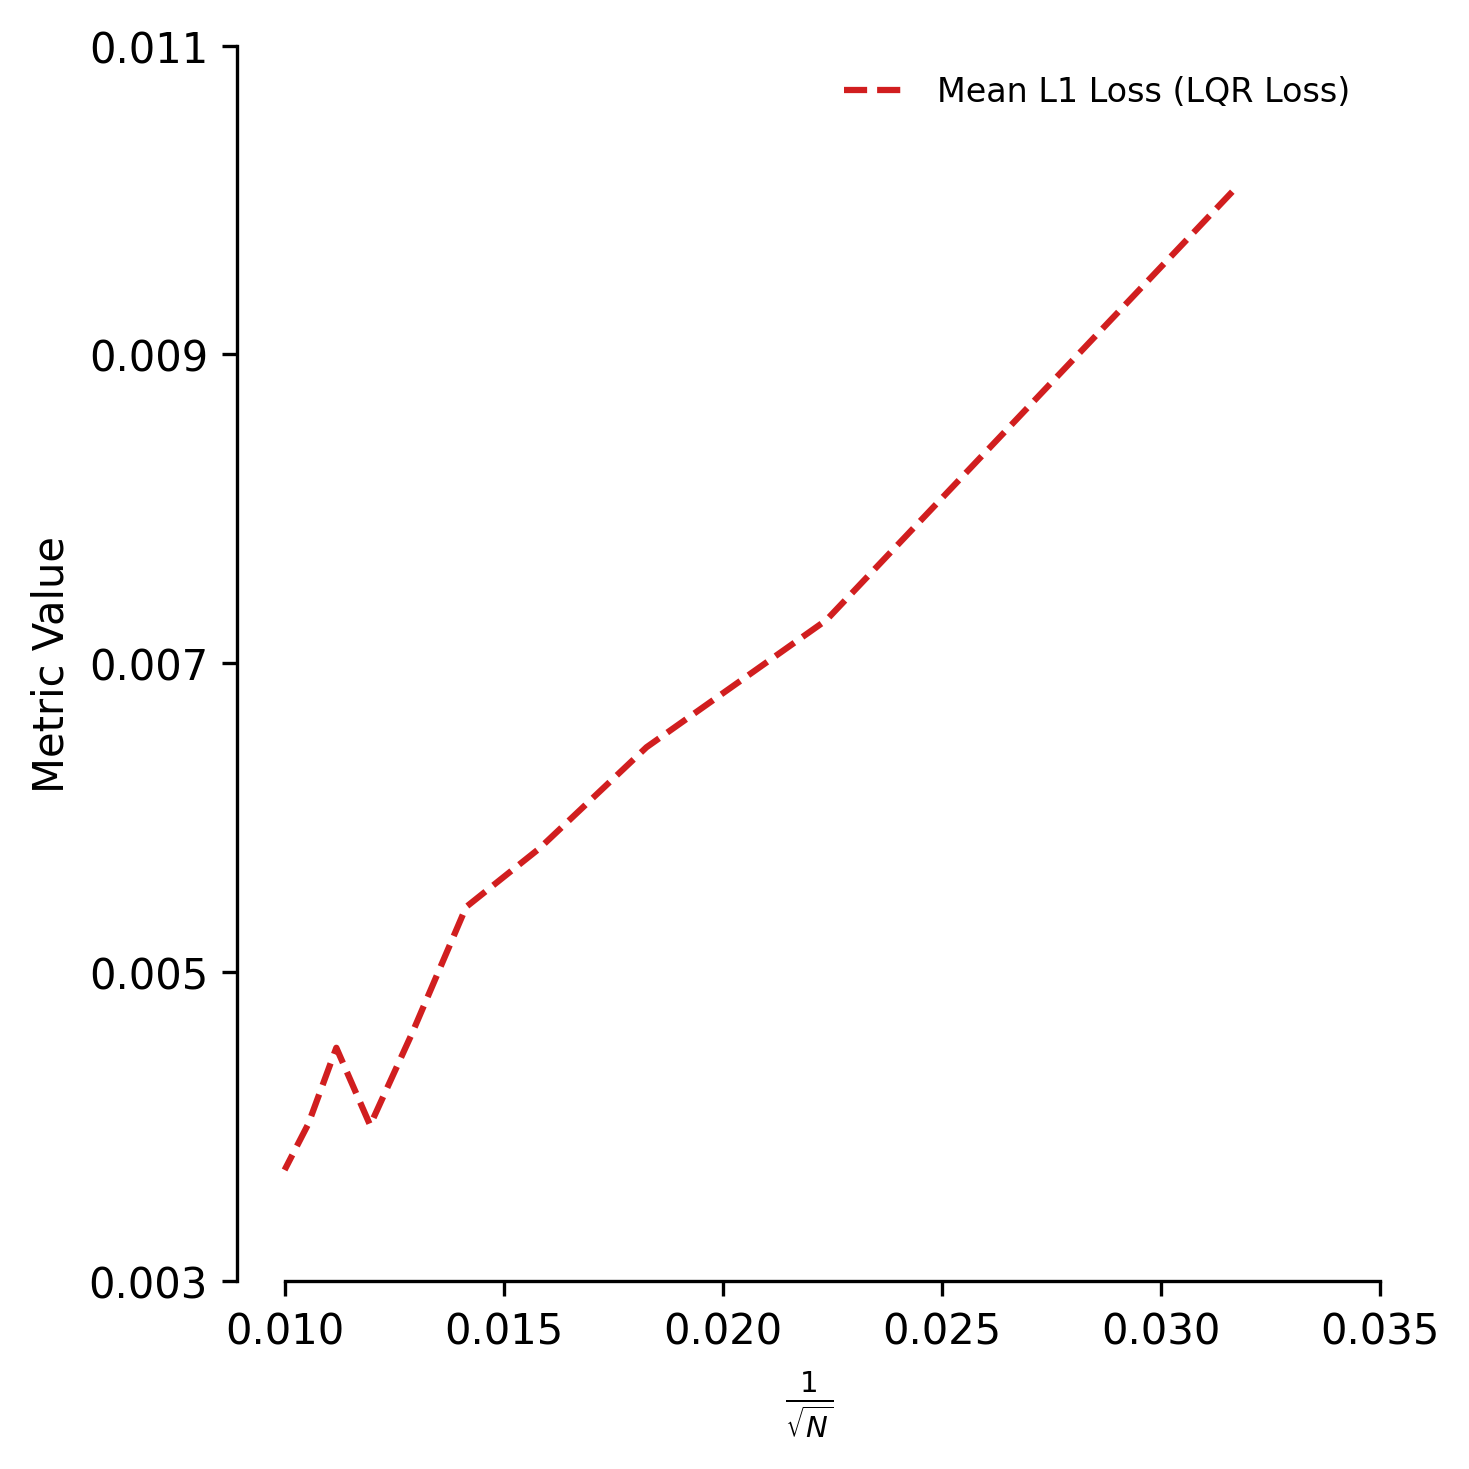

In [ ]:
import seaborn as sns
# Data extraction
N_values = list(final_results.keys())
#mean_op_mse_results = [final_results[p]['mean_op_mse_results'] for p in p_values]
mean_lqr_L_1_results = [final_results[N]['mean_lqr_L_1_results'] for N in N_values]
#mean_relative_l2_results = [final_results[p]['mean_relative_l2_results'] for p in p_values]

# Create the figure using the provided template
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

# Set up color palettes
#colors = sns.color_palette("Blues", 10)
colors1 = sns.color_palette("Reds", 10)
#colors2 = sns.color_palette("Greens", 10)

# Plot all three metrics in one plot
#ax.plot(p_values, mean_op_mse_results, color=colors[7], linewidth=1.5, label='Mean MSE (Optimal Control)', linestyle='-')
ax.plot(1/np.sqrt(N_values), mean_lqr_L_1_results, color=colors1[7], linewidth=1.5, label='Mean L1 Loss (LQR Loss)', linestyle='--')
#ax.plot(p_values, mean_relative_l2_results, color=colors2[7], linewidth=1.5, label='Mean Relative L2 Norm (Optimal Control)', linestyle='-.')

# Customize the axes
ax.set_yticks([ 0.003, 0.005, 0.007, 0.009, 0.011])
ax.set_xticks([0.01, 0.015, 0.02, 0.025, 0.03, 0.035])
ax.set_ylabel(r'Metric Value', fontsize=10)
ax.set_xlabel(r'$\frac{1}{\sqrt{N}}$', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_bounds(0.003, 0.011)
ax.spines['bottom'].set_bounds(0.01, 0.035)
ax.legend(frameon=False, fontsize=8)

# Layout adjustments
plt.tight_layout()
plt.show()